In [3]:
%%bash
set -ex

uv sync
uv run bash scripts/run_data_selection.sh 2
uv run bash scripts/run_data_selection.sh 42
uv run bash scripts/run_data_selection.sh 36
sleep 1000



+ uv sync
Resolved 195 packages in 1ms
Checked 191 packages in 3ms
+ uv run bash scripts/run_data_selection.sh 2


PYTHONPATH set to: /home/huangyaohui/hyh/subset-knn-shapley-code1:


Precomputing embeddings for dataset=imdb-embedding (train_size=3000, test_size=1000)...


[precompute] imdb-embedding (train_size=3000, test_size=1000, seed=2)
[precompute] done


Scheduling experiment: ver=point_add_10, dataset=imdb-embedding, model=logistic-regression, method=all, F=
Using train_size=3000, test_size=1000, max_points=400
Starting experiment: ver=point_add_10, dataset=imdb-embedding, model=logistic-regression, method=all
Random seed: 2


...

Scheduling experiment: ver=point_add_10, dataset=imdb-embedding, model=logistic-regression, method=all, F=
Using train_size=3000, test_size=1000, max_points=400
Starting experiment: ver=point_add_10, dataset=imdb-embedding, model=logistic-regression, method=all
Random seed: 36


Waiting for all experiments to complete...


scripts/run_data_selection.sh: line 173: wait: pid 2360856 is not a child of this shell


Experiment with PID 2360856 completed
All experiments completed!
Log files saved at: ../exps/logs/


+ sleep 1000


In [4]:
%%bash
set -ex

uv run jupyter nbconvert --to notebook --execute exps/plot_legend.ipynb --output plot_legend.executed.ipynb


+ uv run jupyter nbconvert --to notebook --execute exps/plot_legend.ipynb --output plot_legend.executed.ipynb
[NbConvertApp] Converting notebook exps/plot_legend.ipynb to notebook
[IPKernelApp] WARNING | Kernel is running over TCP without encryption. All communication (including code and outputs) is sent in plain text and is susceptible to eavesdropping. Use IPC transport or launch with kernel manager-provisioned CurveZMQ keys to enable transport encryption.
[NbConvertApp] Writing 14600 bytes to exps/plot_legend.executed.ipynb


In [5]:
%%bash
set -ex

uv run jupyter nbconvert --to notebook --execute exps/mylog_visualization.ipynb --output mylog_visualization.executed.ipynb


+ uv run jupyter nbconvert --to notebook --execute exps/mylog_visualization.ipynb --output mylog_visualization.executed.ipynb
[NbConvertApp] Converting notebook exps/mylog_visualization.ipynb to notebook
[IPKernelApp] WARNING | Kernel is running over TCP without encryption. All communication (including code and outputs) is sent in plain text and is susceptible to eavesdropping. Use IPC transport or launch with kernel manager-provisioned CurveZMQ keys to enable transport encryption.
[NbConvertApp] Writing 169878 bytes to exps/mylog_visualization.executed.ipynb


**PDF generated:** [imdb-embedding_logistic-regression_train2700_b400_shape768_g00.pdf](/home/huangyaohui/hyh/subset-knn-shapley-code1/exps/pics/imdb-embedding_logistic-regression_train2700_b400_shape768_g00.pdf)

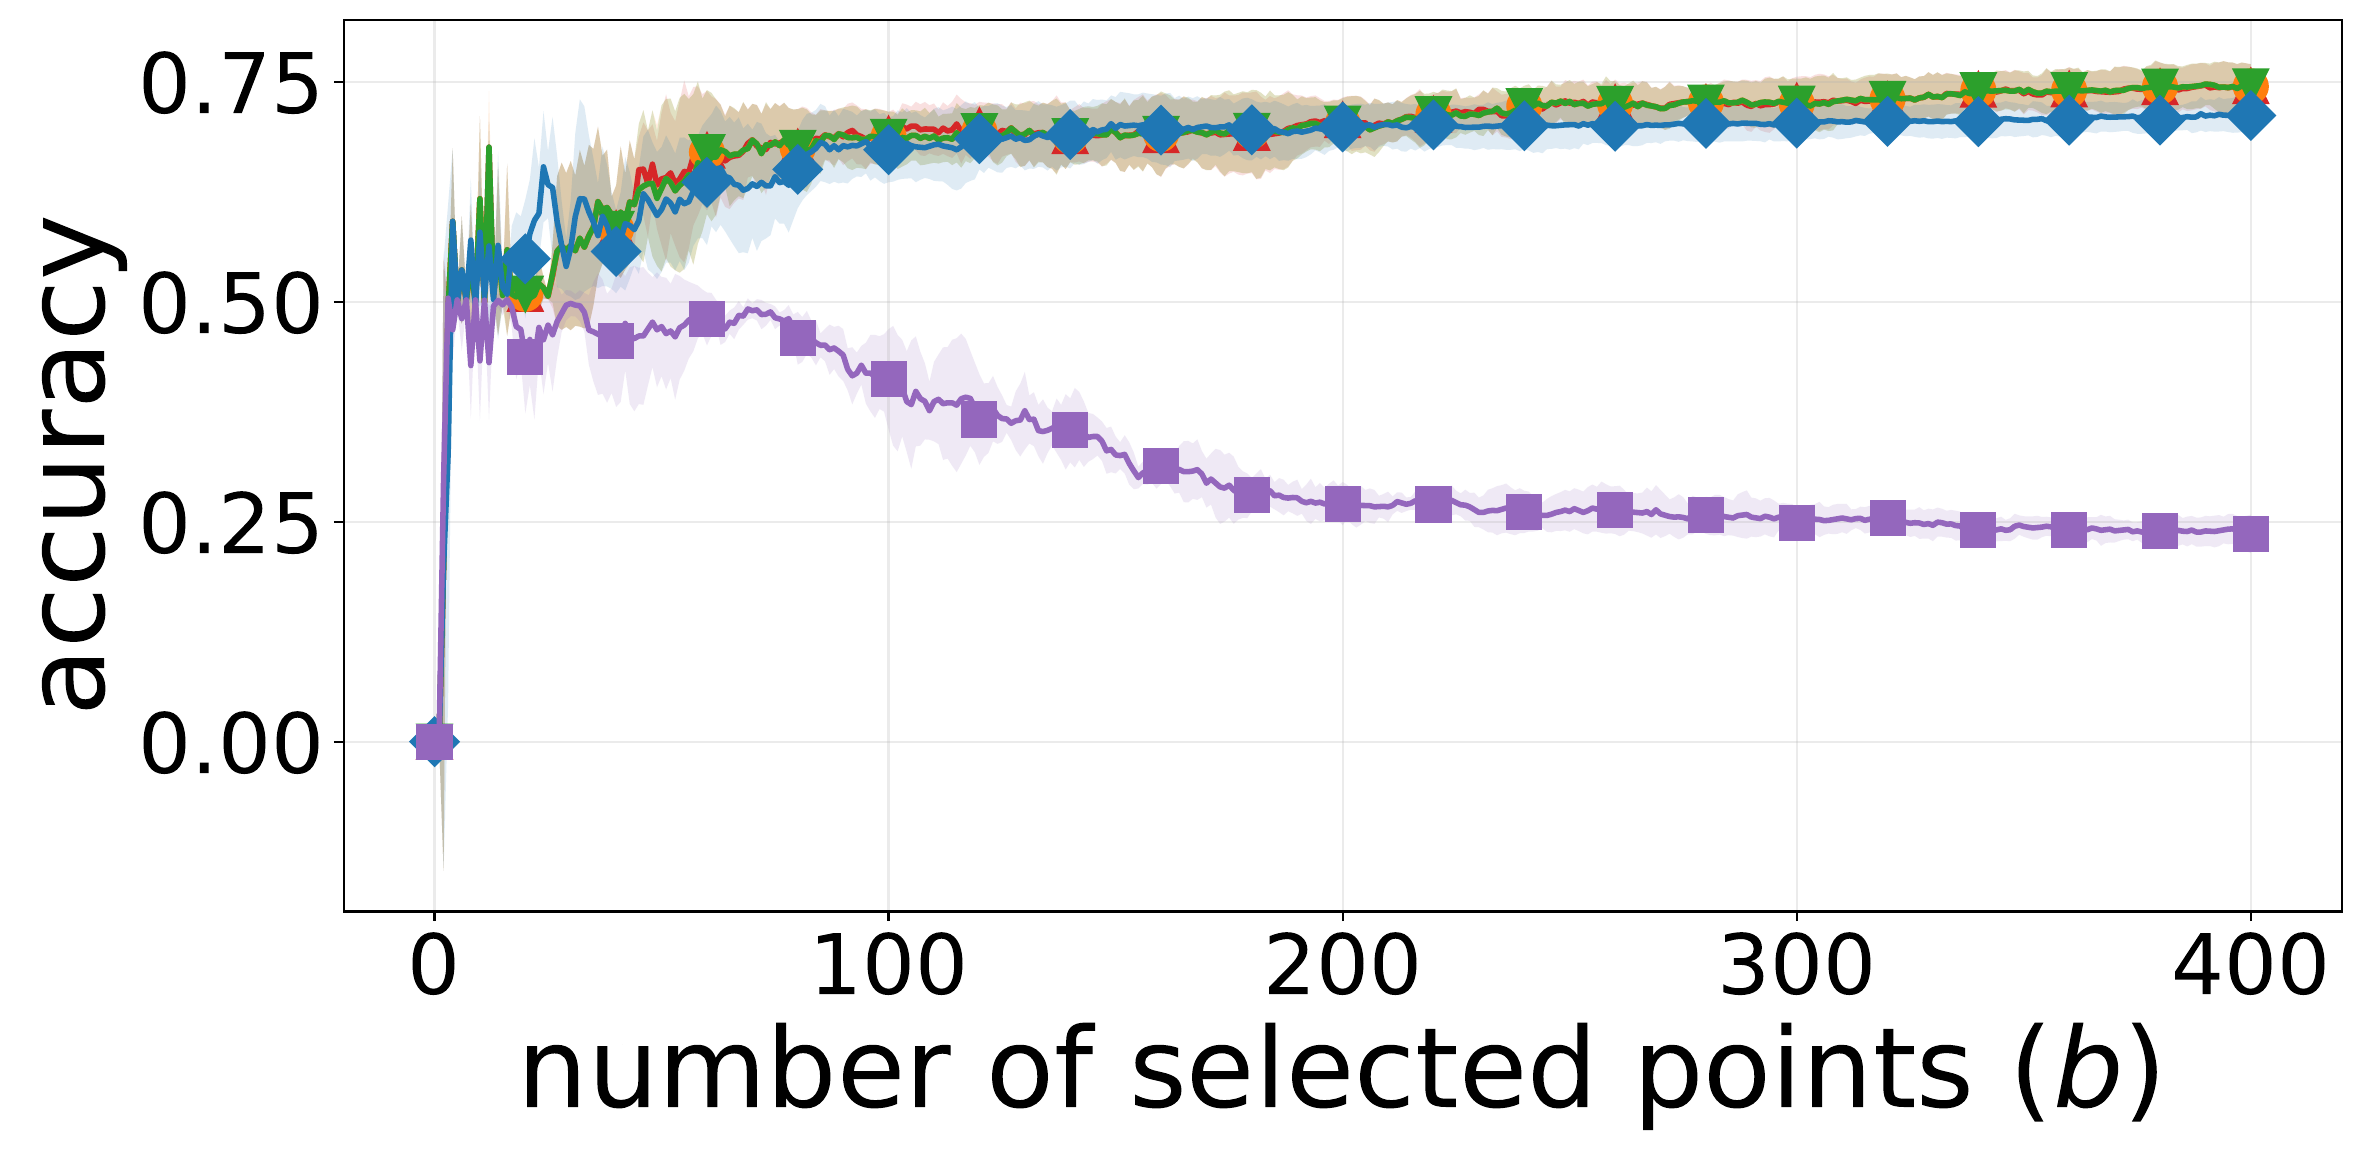

**PDF generated:** [method_legend.pdf](/home/huangyaohui/hyh/subset-knn-shapley-code1/exps/pics/method_legend.pdf)

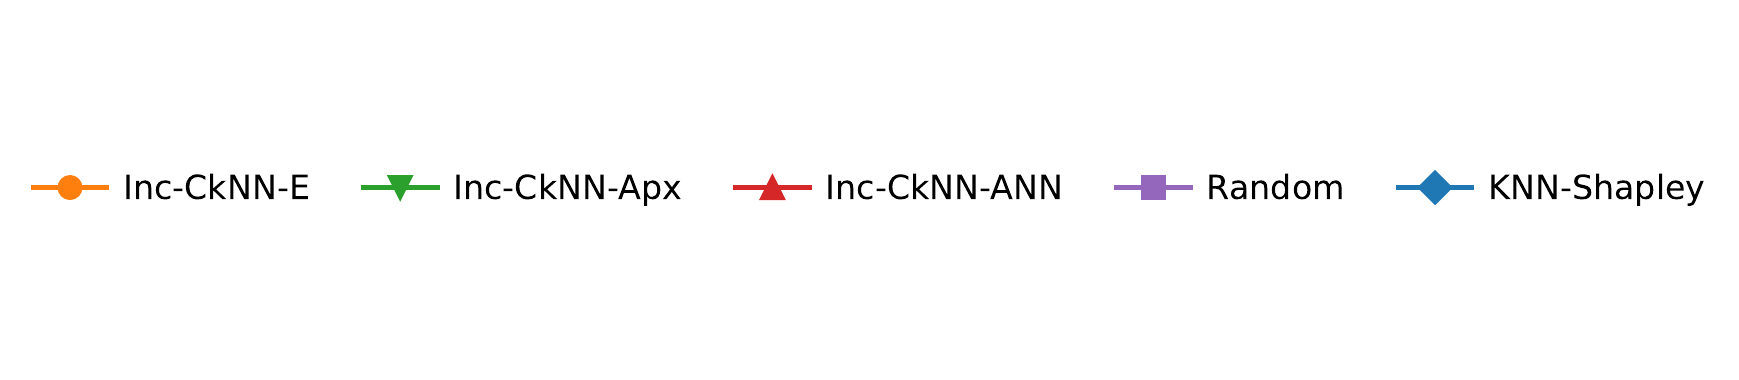

In [6]:
from pathlib import Path
from IPython.display import Image, display, Markdown

pics_dir = Path.cwd() / "exps" / "pics"
image_extensions = {".png", ".jpg", ".jpeg", ".gif"}

if not pics_dir.exists():
    display(Markdown(f"No figures directory found: `{pics_dir}`"))
else:
    files = sorted(pics_dir.iterdir())
    if not files:
        display(Markdown(f"No files found in `{pics_dir}`"))

    for path in files:
        suffix = path.suffix.lower()
        if suffix in image_extensions:
            display(Markdown(f"**Displaying image:** `{path.name}`"))
            display(Image(filename=str(path)))
        elif suffix == ".pdf":
            display(Markdown(f"**PDF generated:** [{path.name}]({path})"))
            try:
                from pdf2image import convert_from_path

                pages = convert_from_path(str(path), first_page=1, last_page=1)
                if pages:
                    preview_path = pics_dir / f".preview_{path.stem}.png"
                    pages[0].save(preview_path, "PNG")
                    display(Image(filename=str(preview_path)))
                    preview_path.unlink(missing_ok=True)
            except Exception as exc:
                display(Markdown(
                    "PDF preview skipped. To enable it on macOS, run "
                    "`brew install poppler` and `uv add pdf2image`.\n\n"
                    f"Error: `{exc}`"
                ))
